# Unsupervised Learning Project: Dimensionality Reduction on Images using PCA

## Project Overview

In this project, we will explore **Unsupervised Learning** through the lens of **Dimensionality Reduction**. We will use **Principal Component Analysis (PCA)** to analyze a high-dimensional image dataset.

Unlike supervised learning where we predict a label, or clustering where we find distinct groups, the goal of PCA is to simplify the data while keeping the most important information. We will try to answer the question: "Can we compress these images into fewer numerical values without losing what makes them recognizable?"

### The Dataset: Fashion-MNIST
We will use the Fashion-MNIST dataset. It consists of 70,000 grayscale images of 10 different categories of clothing (T-shirts, trousers, sneakers, etc.).

* **Image Size:** 28x28 pixels.
* **Dimensions:** Each image is initially a high-dimensional vector of $28 \times 28 = 784$ features (pixels).

### Objectives:
1.  **Understand Image Data as Vectors:** Treat pixels as individual features.
2.  **Determine Optimal Components:** Use explained variance to decide how many dimensions we actually need.
3.  **Visualize "Eigenimages":** See what the Principal Components actually look like when reshaped back into images.
4.  **Data Visualization:** Compress 784 dimensions down to 2D to visualize the structure of the clothing data.
5.  **Image Reconstruction:** Compress images and then reconstruct them to see information loss visually.

---

## Section 1: Setup and Data Loading

Let's import necessary libraries. We need `numpy` for numerical operations, `matplotlib` for plotting, and `sklearn` for the dataset and PCA algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Setting plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Libraries Imported successfully.")

Libraries Imported successfully.


### Loading Fashion-MNIST
We will fetch the data using Scikit-learn's helper function. This might take a minute the first time run.

In [2]:
# Fetch the data
print("Loading dataset... this may take a moment.")
mnist = fetch_openml('Fashion-MNIST', version=1, cache=True, as_frame=False)

# X contains the pixel values (features), y contains the labels (clothing type)
X_raw = mnist.data
y_raw = mnist.target.astype(int)

print("Shape of Data (X):", X_raw.shape)
print("Shape of Labels (y):", y_raw.shape)

# Label mapping for easier interpretation later
label_map = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

Loading dataset... this may take a moment.
Shape of Data (X): (70000, 784)
Shape of Labels (y): (70000,)


---

## Section 2: Exploratory Data Analysis (Visualizing the Input)

Before we apply PCA, it's crucial to understand what our data looks like. 

The data is currently loaded as rows of 784 numbers. To view them as images, we must reshape a row back into a 28x28 matrix.

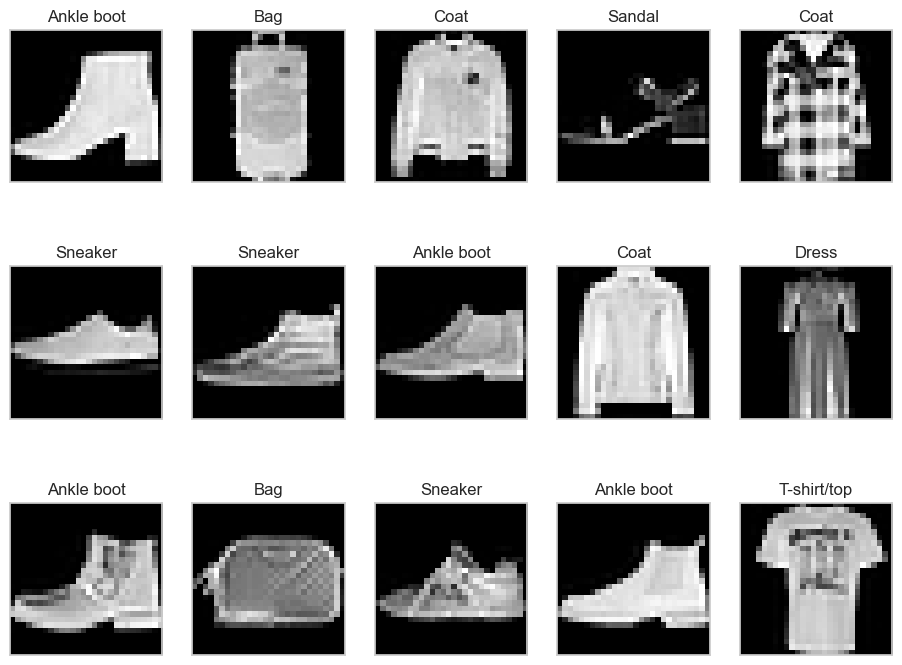

In [3]:
def plot_gallery(images, titles, h, w, n_row=3, n_col=5):
    """Helper function to plot a grid of images in a compact layout."""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        if i < len(images):
            plt.subplot(n_row, n_col, i + 1)
            plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
            plt.title(titles[i], size=12)
            plt.xticks(())
            plt.yticks(())
    plt.show()

h, w = 28, 28

sample_indices = np.random.choice(np.arange(len(X_raw)), 15, replace=False)
sample_images = X_raw[sample_indices]
sample_titles = [label_map[y_raw[i]] for i in sample_indices]

plot_gallery(sample_images, sample_titles, h, w)

---

## Section 3: Data Preprocessing (Crucial Step!)

### 3.1 Data Splitting
Even though this is unsupervised, it's good practice to keep a test set separate to verify reconstructions later. We will use a smaller subset of the data for training to speed up computations in this notebook.

In [4]:
# Use a subset of 15,000 images for training to speed up PCA
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, train_size=15000, test_size=5000, random_state=42, stratify=y_raw)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (15000, 784)
Testing data shape: (5000, 784)


### 3.2 Feature Scaling (Standardization)

**Why standardize images?**
PCA is highly sensitive to the scale of the data because it seeks directions of maximum variance. 

In image data, pixel values usually range from 0 to 255. However, some pixels (like those in the corners) might always be black (variance = 0), while center pixels vary wildly. If we don't standardize, PCA will focus excessively on the pixels with naturally high variance, potentially ignoring subtle but important patterns elsewhere.

We use `StandardScaler` to make every pixel feature have a mean of 0 and a standard deviation of 1.

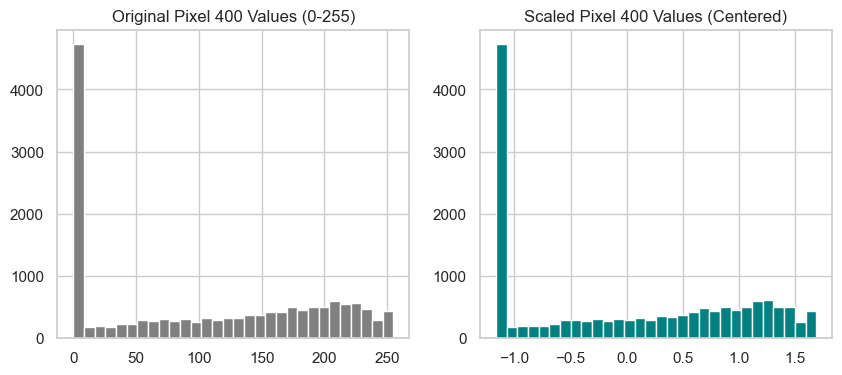

In [5]:
scaler = StandardScaler()

# Fit on training set only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Show the effect of scaling on a single pixel across the dataset
# Pixel 400 is roughly in the middle of the image
pixel_index = 400

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(X_train[:, pixel_index], bins=30, color='gray')
plt.title(f"Original Pixel {pixel_index} Values (0-255)")

plt.subplot(1, 2, 2)
plt.hist(X_train_scaled[:, pixel_index], bins=30, color='teal')
plt.title(f"Scaled Pixel {pixel_index} Values (Centered)")
plt.show()

---

## Section 4: Applying PCA and Determining Components

Now we apply PCA. Initially, we won't choose a specific number of components. We will let PCA compute all possible components so we can analyze how much "information" (variance) each one holds.

In [6]:
# Initialize PCA without specifying n_components to compute all of them
pca_full = PCA(random_state=42)

print("Training PCA model...")
# Fit PCA on the scaled training data
pca_full.fit(X_train_scaled)
print("Done.")

# The amount of variance explained by each of the 784 components
variance_ratios = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratios)

print(f"Variance explained by Top 1 component: {variance_ratios[0]:.2%}")
print(f"Variance explained by Top 10 components: {np.sum(variance_ratios[:10]):.2%}")

Training PCA model...
Done.
Variance explained by Top 1 component: 21.94%
Variance explained by Top 10 components: 62.04%


### Visualization 1: The Cumulative Explained Variance Plot (Scree Plot)

This is the most important plot for deciding how many dimensions to keep. We want to find the "elbow" where adding more dimensions provides diminishing returns in captured information.

We often aim to capture eg. 90% or 95% of the total variance.

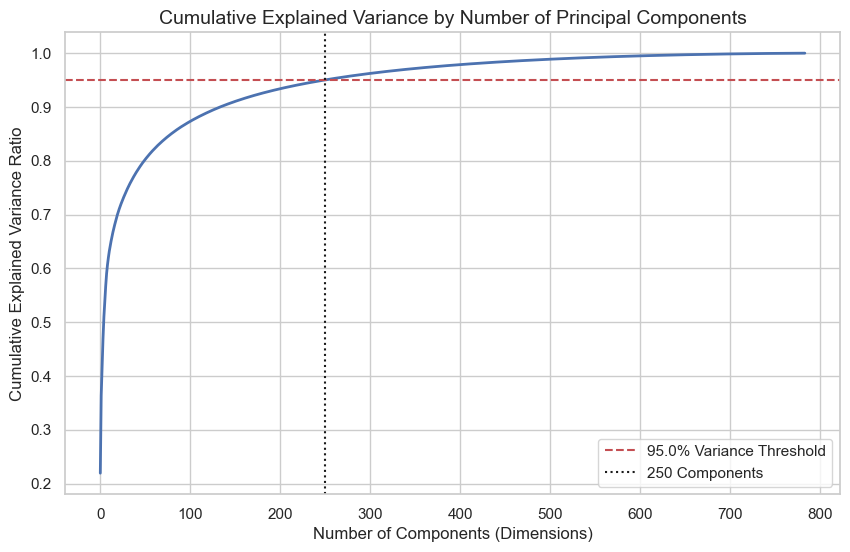

Number of components needed to explain 95.0% variance: 250
Compression ratio: 3.1x smaller


In [7]:
plt.figure(figsize=(10, 6))

# Plot the cumulative variance
plt.plot(cumulative_variance, linewidth=2)

# Add a target line for 95% variance
target_variance = 0.95
plt.axhline(y=target_variance, color='r', linestyle='--', label=f'{target_variance*100}% Variance Threshold')

# Find exactly how many components needed for 95%
n_components_95 = np.argmax(cumulative_variance >= target_variance) + 1
plt.axvline(x=n_components_95, color='k', linestyle=':', label=f'{n_components_95} Components')

plt.title('Cumulative Explained Variance by Number of Principal Components', fontsize=14)
plt.xlabel('Number of Components (Dimensions)', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Number of components needed to explain {target_variance*100}% variance: {n_components_95}")
print(f"Compression ratio: {784/n_components_95:.1f}x smaller")

**Observation:** 
We can see that we don't need all 784 pixels. We can achieve 95% of the information using only around 200-300 components. This is a significant reduction in data size!

---

## Section 5: Visualizing Principal Components ("Eigenimages")

This is the unique aspect of doing PCA on images. 

Each principal component is a vector of weights consisting of 784 elements (one weight per pixel). These weights tell us how important that specific pixel is for that specific component.

Because these components are vectors of length 784, **we can reshape them back into 28x28 images and view them.** These are often called "eigenfaces" (if dealing with faces) or in our case, "eigenclothing".

They represent the fundamental "building blocks" or abstract patterns that exist in the dataset. Any image in the dataset can be reconstructed by adding together different amounts of these ghost-like images.

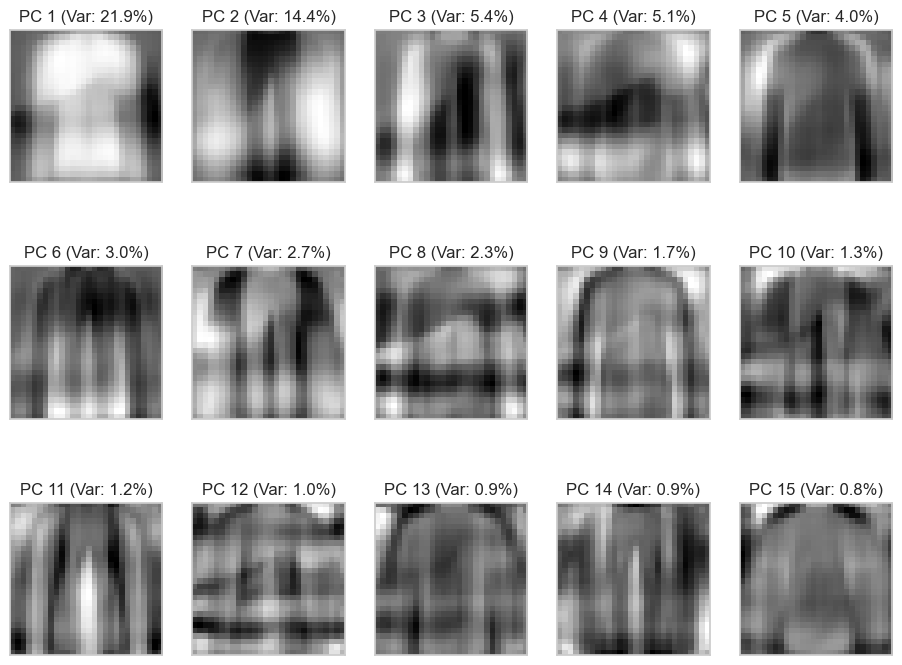

<Figure size 640x480 with 0 Axes>

In [8]:
eigenimages = pca_full.components_.reshape((784, h, w))

# Plot the first 15 principal components
titles = [f"PC {i+1} (Var: {variance_ratios[i]:.1%})" for i in range(15)]
plot_gallery(eigenimages, titles, h, w, n_row=3, n_col=5)
plt.suptitle("Top 15 'Eigenimages' (Principal Components)", fontsize=16, y=1.02)
plt.show()

**Interpreting Eigenimages:**

* **PC 1:** Usually captures the most general shape. Here, it looks like a generic "blob" in the center, distinguishing between items that fill the space (like coats) vs thin items (like sandals).
* **PC 2:** Often captures the next biggest variation. It seems to be detecting vertical structures, perhaps distinguishing trousers or the sides of shirts.
* **Later PCs (e.g., PC 10+):** Start capturing increasingly fine details, like the specific curve of a sneaker or the neckline of a shirt.

---

## Section 6: Dimensionality Reduction for 2D Visualization

One of the most practical uses of PCA is visualizing high-dimensional data. We cannot imagine 784 dimensions, but we can easily understand a 2D scatter plot.

Let's compress the data down to just **2 principal components** and plot them. We will color the dots by their actual clothing label to see if PCA naturally grouped similar items together.

New shape of data: (15000, 2)


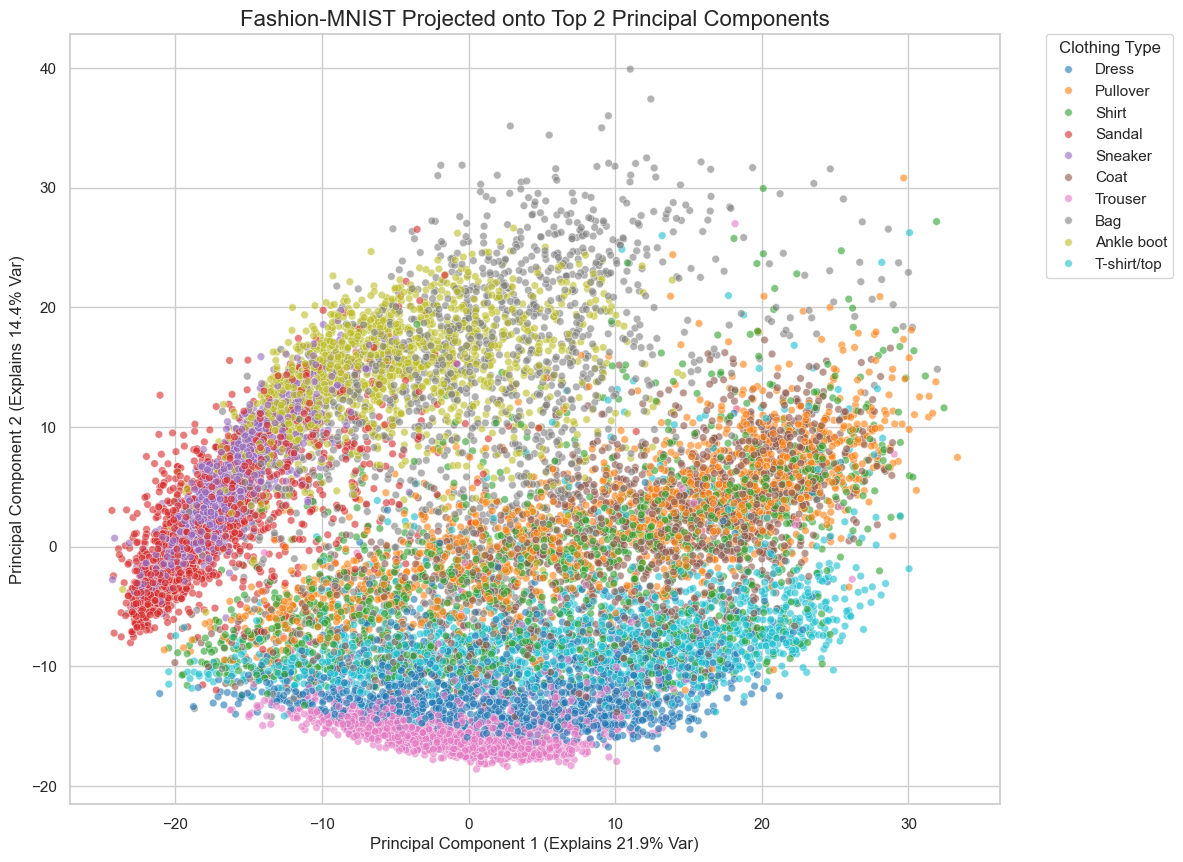

In [9]:
# Apply PCA to reduce to 2 dimensions
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

print(f"New shape of data: {X_train_2d.shape}")

# Visualization Plotting
plt.figure(figsize=(12, 10))

# Use seaborn scatterplot for easier handling of labels and legends
sns.scatterplot(
    x=X_train_2d[:, 0], 
    y=X_train_2d[:, 1],
    hue=[label_map[label] for label in y_train], # Map numeric labels to text
    palette="tab10",
    alpha=0.6,
    s=30
)

plt.title("Fashion-MNIST Projected onto Top 2 Principal Components", fontsize=16)
plt.xlabel(f"Principal Component 1 (Explains {pca_2d.explained_variance_ratio_[0]:.1%} Var)", fontsize=12)
plt.ylabel(f"Principal Component 2 (Explains {pca_2d.explained_variance_ratio_[1]:.1%} Var)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Clothing Type")
plt.show()

**Analysis of 2D Projection:**

This plot is fascinating! Even though PCA had **no access to the labels (y)**, it has managed to separate the distinct types of clothing based purely on pixel patterns.

* **Clusters:** Notice how "Trouser" (orange) forms a very distinct cluster away from everything else. "Footwear" items (Sneaker, Sandal, Ankle boot) also cluster together in the bottom left.
* **Overlap:** Items that look similar visually, like "Shirt", "T-shirt/top", "Pullover", and "Coat", overlap significantly in the center. This makes sense, as they share similar general shapes.

This proves that the first two principal components have captured meaningful structures in the image data.

---

## Section 7: Image Reconstruction (Inverse Transform)

The final and perhaps most magical demonstration of PCA is image reconstruction.

We can take an image, compress it down to $N$ components, and then use the inverse transformation to reconstruct an approximation of the original 784 pixels.

We will compare reconstructions using different numbers of components to visualize information loss.

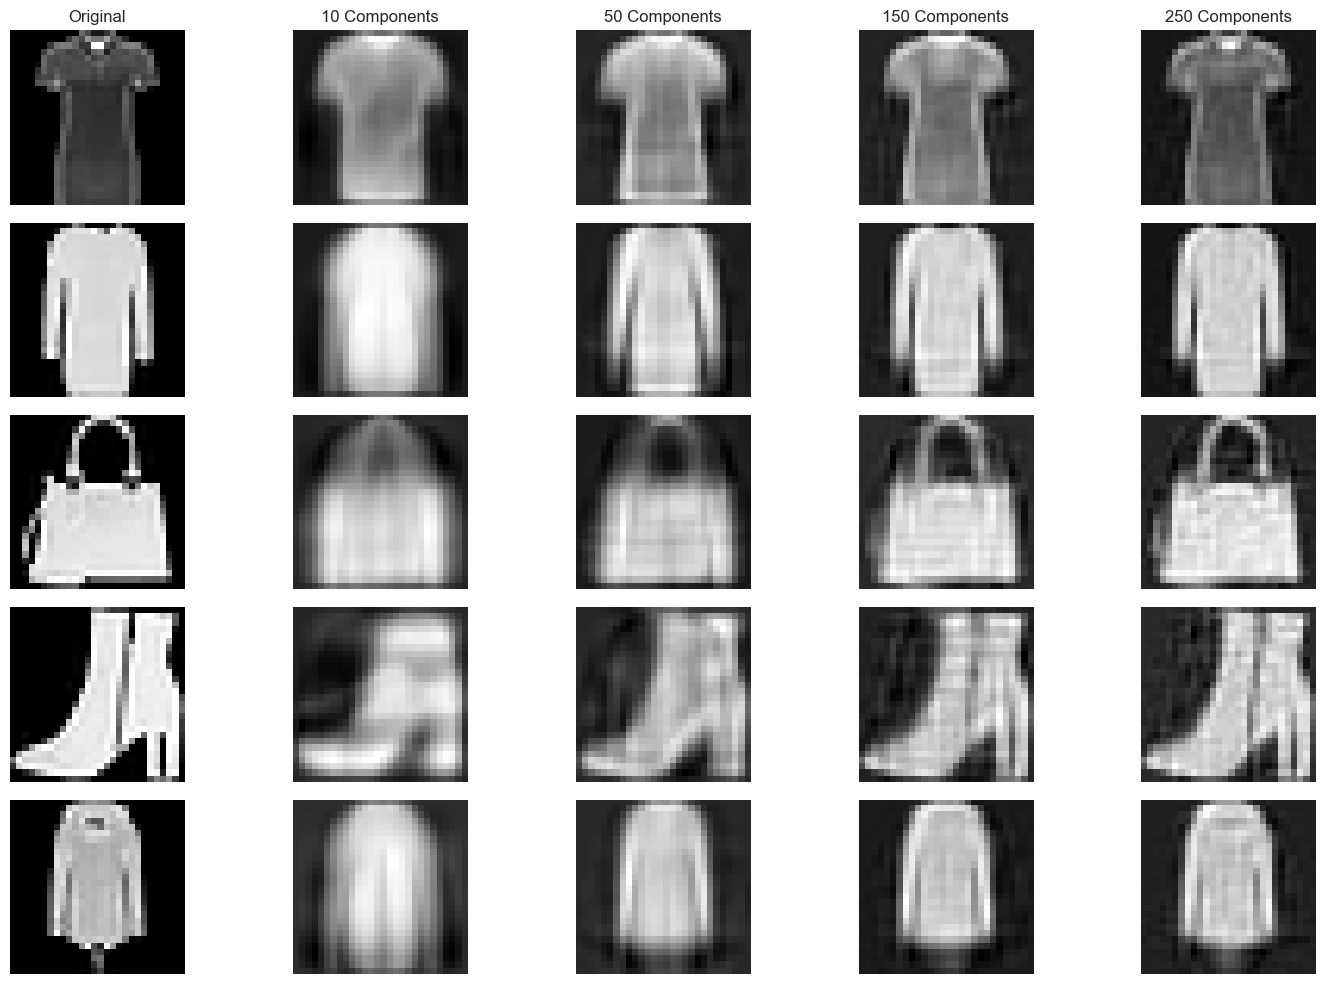

In [10]:
# Select a few test images to reconstruct
n_samples_to_show = 5
test_indices = np.random.choice(len(X_test_scaled), n_samples_to_show, replace=False)
X_test_samples = X_test_scaled[test_indices]
original_images_unscaled = X_test[test_indices] # For comparison

# Define different levels of compression
components_list = [10, 50, 150, n_components_95] 

plt.figure(figsize=(15, 10))

# Plot originals in first column
for i in range(n_samples_to_show):
    plt.subplot(n_samples_to_show, len(components_list) + 1, i * (len(components_list) + 1) + 1)
    plt.imshow(original_images_unscaled[i].reshape(h, w), cmap='gray')
    if i == 0: plt.title("Original", fontsize=12)
    plt.axis('off')

# Perform reconstruction for different component counts
for col_idx, n_comp in enumerate(components_list):
    # 1. Fit PCA with n components
    pca_temp = PCA(n_components=n_comp, random_state=42)
    pca_temp.fit(X_train_scaled)
    
    # 2. Transform (compress) the test samples
    X_compressed = pca_temp.transform(X_test_samples)
    
    # 3. Inverse transform (reconstruct) back to 784 dimensions
    X_reconstructed_scaled = pca_temp.inverse_transform(X_compressed)
    
    # 4. Inverse transform the scaling (standardization) to get back to pixel space
    X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)

    # Plot reconstructions
    for i in range(n_samples_to_show):
        plt.subplot(n_samples_to_show, len(components_list) + 1, i * (len(components_list) + 1) + col_idx + 2)
        plt.imshow(X_reconstructed[i].reshape(h, w), cmap='gray')
        if i == 0: plt.title(f"{n_comp} Components", fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()

**Reconstruction Analysis:**

* **10 Components:** The images are very blurry. Only the most basic shapes (like the general outline of a t-shirt vs a trouser) are retained. Much of the variance is lost.
* **50 Components:** The items become clearly recognizable, though fine details (like laces on sneakers or logos on shirts) are missing.
* **150+ Components:** The reconstruction is nearly indistinguishable from the original to the human eye, yet it requires significantly less data storage than the original 784 pixels.

## Project Conclusion

Through this project, we successfully used unsupervised learning to analyze image data.

1.  We determined via the **Cumulative Variance Plot** that we could reduce the dataset dimension by roughly 4x (from 784 down to ~190) while retaining 95% of the information.
2.  We visualized the **Eigenimages**, understanding that PCA breaks down images into abstract "ghost" layers.
3.  We projected the data into **2D**, discovering that PCA naturally clustered similar clothing items together without ever seeing their labels.
4.  We demonstrated **Image Compression and Reconstruction**, visually confirming how adding more principal components leads to sharper images.

This powerful technique is foundational for many advanced computer vision tasks, including facial recognition and image compression.